# 5.1 Introduction to Boundary Value Problem

In [1]:
using CairoMakie
using LinearAlgebra
using LinearSolve
using SparseArrays
using BenchmarkTools

In this notebook, we are going to find the temperature distribution of a uniformly heated plate. From physics, the governing equation can be written as

$\frac{d}{dx}\left(k\frac{dT}{dx}\right)=-q(x)$

We usually assume that $k$ is a constant so the above equation can be simplified to be

$k\frac{d^2T}{dx^2}=-q(x)$

For uniform heating, $q(x)=1$. Assume that $x\in[0,1]$ with the boundary conditions  $T(x=0)=5$ and $dT/dx(x=1)=0$.   We want to find how $T$ changes with $x$.  Assume that $k=0.1$

Using the finite difference approximation


$\frac{d^2T}{dx^2}\approx\frac{T_{i-1}-2T_i+T_{i+1}}{\Delta^2}$ 

So at every point in the domain, we will have 

$k\frac{d^2T}{dx^2}\approx\frac{T_{i-1}-2T_i+T_{i+1}}{\Delta^2}=-1$ 

We will now split our domain into 5 sub intervals and apply the equation above onto each of the interior points

In [2]:
Delta=0.2
x=0:Delta:1
α=5.0
ThermalConductivity=0.1

0.1

$k\frac{d^2T}{dx^2}(x_i=x_2)\approx\frac{T_{1}-2T_2+T_{3}}{\Delta^2}=-1$ 

$k\frac{d^2T}{dx^2}(x_i=x_3)\approx\frac{T_{2}-2T_3+T_{4}}{\Delta^2}=-1$ 

$k\frac{d^2T}{dx^2}(x_i=x_4)\approx\frac{T_{3}-2T_4+T_{5}}{\Delta^2}=-1$

$k\frac{d^2T}{dx^2}(x_i=x_5)\approx\frac{T_{4}-2T_5+T_{6}}{\Delta^2}=-1$ 


We also know that at $T(x=0)=5$, so $T_1=5$.

At $x=1$, we are given that $(T_6-T_5)/\Delta=0$, so $T_6-T_5=0$

We can put this in matrix form as

$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 &0 \\
1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2 & 0 & 0 & 0\\
0 & 1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2 & 0 & 0 \\
0 &  0 & 1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2 & 0  \\
0 &  0 & 0 & 1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2   \\
0 &  0 & 0 & 0 & -1 & 1   \\
\end{bmatrix}\begin{Bmatrix}
T_1\\
T_2\\
T_3\\
T_4\\
T_5\\
T_6\\
\end{Bmatrix}=\begin{Bmatrix}
5\\
-1/k\\
-1/k\\
-1/k\\
-1/k\\
0\\
\end{Bmatrix}
$$

If we solve the equation above, we can get the approximate values of the temperature $T_i$

In [3]:
n=length(x)
d=zeros(n)
dl=zeros(n-1)
du=zeros(n-1)
C=zeros(n)

6-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

The code below constructs the matrix
$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 &0 \\
1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2 & 0 & 0 & 0\\
0 & 1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2 & 0 & 0 \\
0 &  0 & 1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2 & 0  \\
0 &  0 & 0 & 1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2   \\
0 &  0 & 0 & 0 & -1 & 1   \\
\end{bmatrix}\begin{Bmatrix}
T_1\\
T_2\\
T_3\\
T_4\\
T_5\\
T_6\\
\end{Bmatrix}=\begin{Bmatrix}
5\\
-1/k\\
-1/k\\
-1/k\\
-1/k\\
0\\
\end{Bmatrix}
$$

In [4]:
du[1]=0.0
d[1]=1.0
C[1]=5.0
for i=2:n-1
    dl[i-1]=(1.0/Delta^2)
    d[i]=-(2.0/Delta^2)
    du[i]=(1.0/Delta^2)
    C[i]=-1.0/ThermalConductivity
end
dl[n-1]=-1
d[n]=1.0
C[n]=0.0

# Construct the specialized structured matrix
A = Tridiagonal(dl, d, du)

6×6 Tridiagonal{Float64, Vector{Float64}}:
  1.0    0.0     ⋅      ⋅      ⋅     ⋅ 
 25.0  -50.0   25.0     ⋅      ⋅     ⋅ 
   ⋅    25.0  -50.0   25.0     ⋅     ⋅ 
   ⋅      ⋅    25.0  -50.0   25.0    ⋅ 
   ⋅      ⋅      ⋅    25.0  -50.0  25.0
   ⋅      ⋅      ⋅      ⋅    -1.0   1.0

In [5]:
A_sparse = sparse(A)

6×6 SparseMatrixCSC{Float64, Int64} with 16 stored entries:
  1.0    0.0     ⋅      ⋅      ⋅     ⋅ 
 25.0  -50.0   25.0     ⋅      ⋅     ⋅ 
   ⋅    25.0  -50.0   25.0     ⋅     ⋅ 
   ⋅      ⋅    25.0  -50.0   25.0    ⋅ 
   ⋅      ⋅      ⋅    25.0  -50.0  25.0
   ⋅      ⋅      ⋅      ⋅    -1.0   1.0

In [6]:
prob=LinearProblem(A,C)
#@btime y=LinearSolve.solve(prob)
@time Tuniform=LinearSolve.solve(prob)

  3.034487 seconds (18.40 M allocations: 942.663 MiB, 12.16% gc time, 100.00% compilation time)


retcode: Success
u: 6-element Vector{Float64}:
 5.000000000000001
 6.6000000000000005
 7.800000000000001
 8.600000000000001
 9.000000000000002
 9.000000000000002

In [7]:
probSparse=LinearProblem(A_sparse,C)
@time y=LinearSolve.solve(probSparse, UMFPACKFactorization())

  0.104771 seconds (388.91 k allocations: 20.009 MiB, 99.20% compilation time)


retcode: Success
u: 6-element Vector{Float64}:
 5.0
 6.6000000000000005
 7.800000000000001
 8.600000000000001
 9.000000000000002
 9.000000000000002

Note that tridag solver is faster since it is specific for tridiagonal systems.  Sparse solver is for more general sparse matrices, hence it is slower than tridag solver.

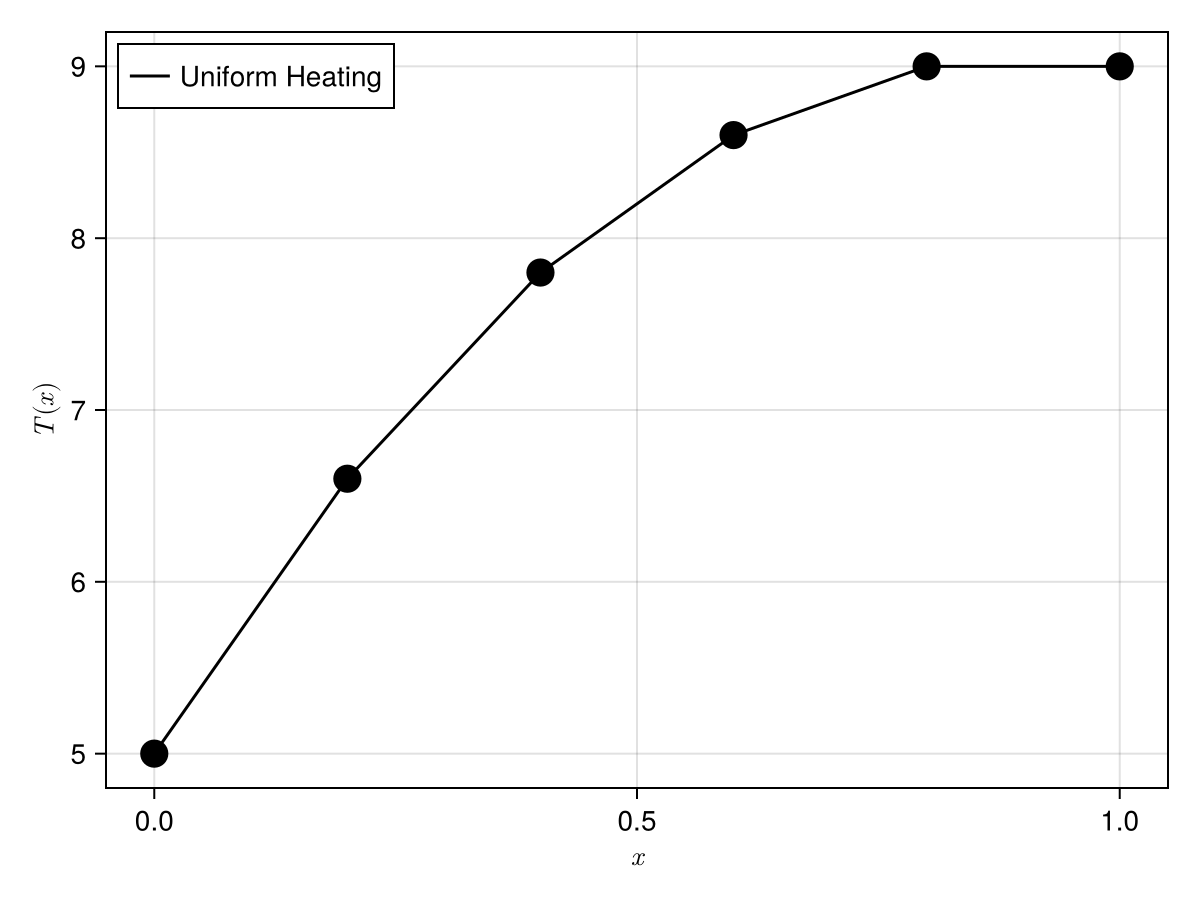

In [15]:
xplot=0:0.01:1
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"T(x)")
lines!(ax,x,Tuniform,color=:black,label="Uniform Heating")
scatter!(ax,x,Tuniform,color=:black,markersize=20)
axislegend(ax,position=:lt)
save("../figures/05p01IntroBVP01.svg",fig)
fig

In [9]:
y[end]

9.000000000000002

---

In this next example, the plate is heated but not uniformly.  The heating increases with $x$ and can be modelled as

$q(x)=(1+2x)$


The governing equation is

$k\frac{\partial^2 T}{\partial x^2}=-q(x)$

We can go through the same steps above to get

The code below constructs the matrix
$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 &0 \\
1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2 & 0 & 0 & 0\\
0 & 1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2 & 0 & 0 \\
0 &  0 & 1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2 & 0  \\
0 &  0 & 0 & 1/\Delta^2 & -2/\Delta^2 & 1/\Delta^2   \\
0 &  0 & 0 & 0 & -1 & 1   \\
\end{bmatrix}\begin{Bmatrix}
T_1\\
T_2\\
T_3\\
T_4\\
T_5\\
T_6\\
\end{Bmatrix}=\begin{Bmatrix}
5\\
-q(x_2)/k\\
-q(x_3)/k\\
-q(x_4)/k\\
-q(x_5)/k\\
0\\
\end{Bmatrix}
$$

In [10]:
for i=2:n-1
    C[i]=-(1.0+2*x[i])/ThermalConductivity
end

In [11]:
prob=LinearProblem(A,C)
#@btime y=LinearSolve.solve(prob)
@time Tlinear=LinearSolve.solve(prob)

  0.000009 seconds (20 allocations: 1.188 KiB)


retcode: Success
u: 6-element Vector{Float64}:
  4.999999999999992
  8.199999999999994
 10.839999999999996
 12.76
 13.800000000000002
 13.800000000000004

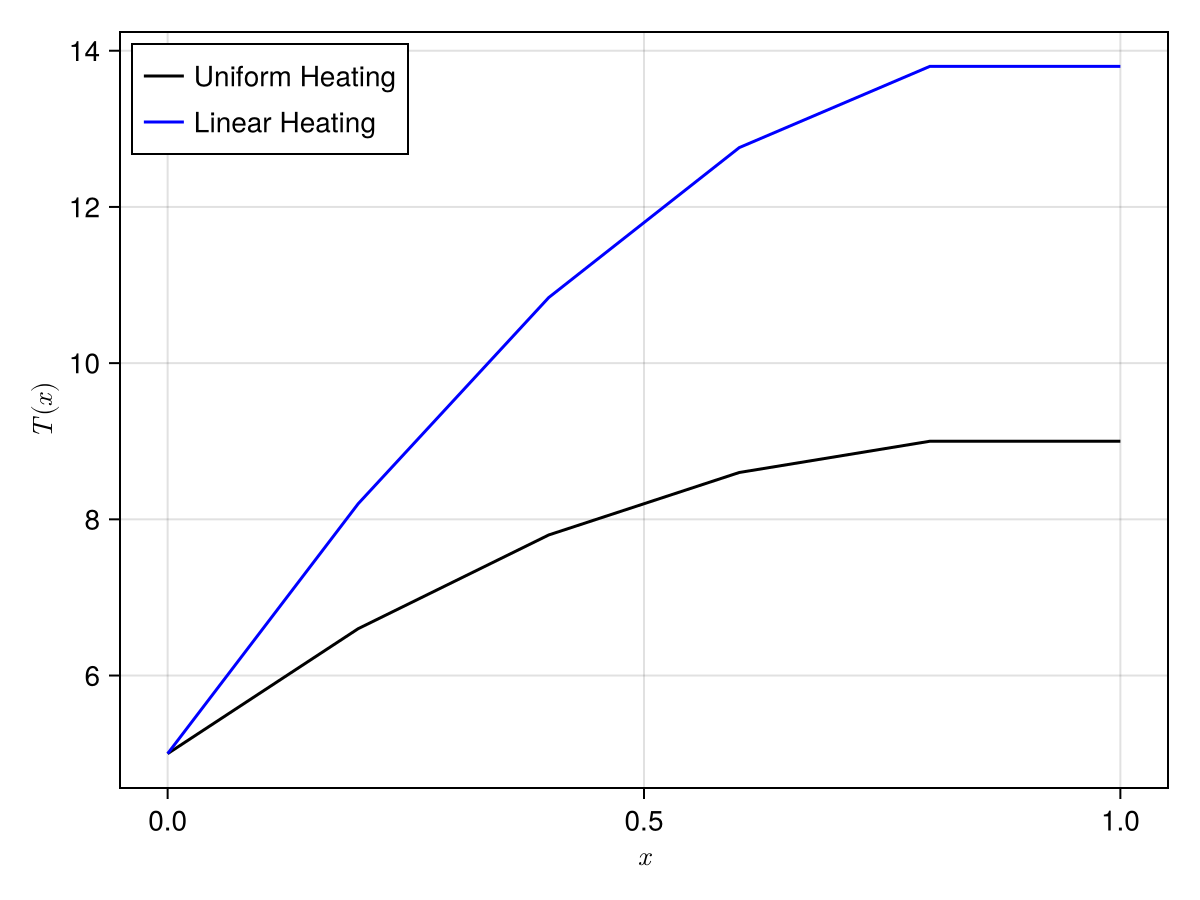

In [12]:
xplot=0:0.01:1
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x", ylabel = L"T(x)")
lines!(ax,x,Tuniform,color=:black,label="Uniform Heating")
lines!(ax,x,Tlinear,color=:blue,label="Linear Heating")
axislegend(ax,position=:lt)
fig